<a href="https://colab.research.google.com/github/mochaditya2005-design/tranformasi-citra/blob/main/PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

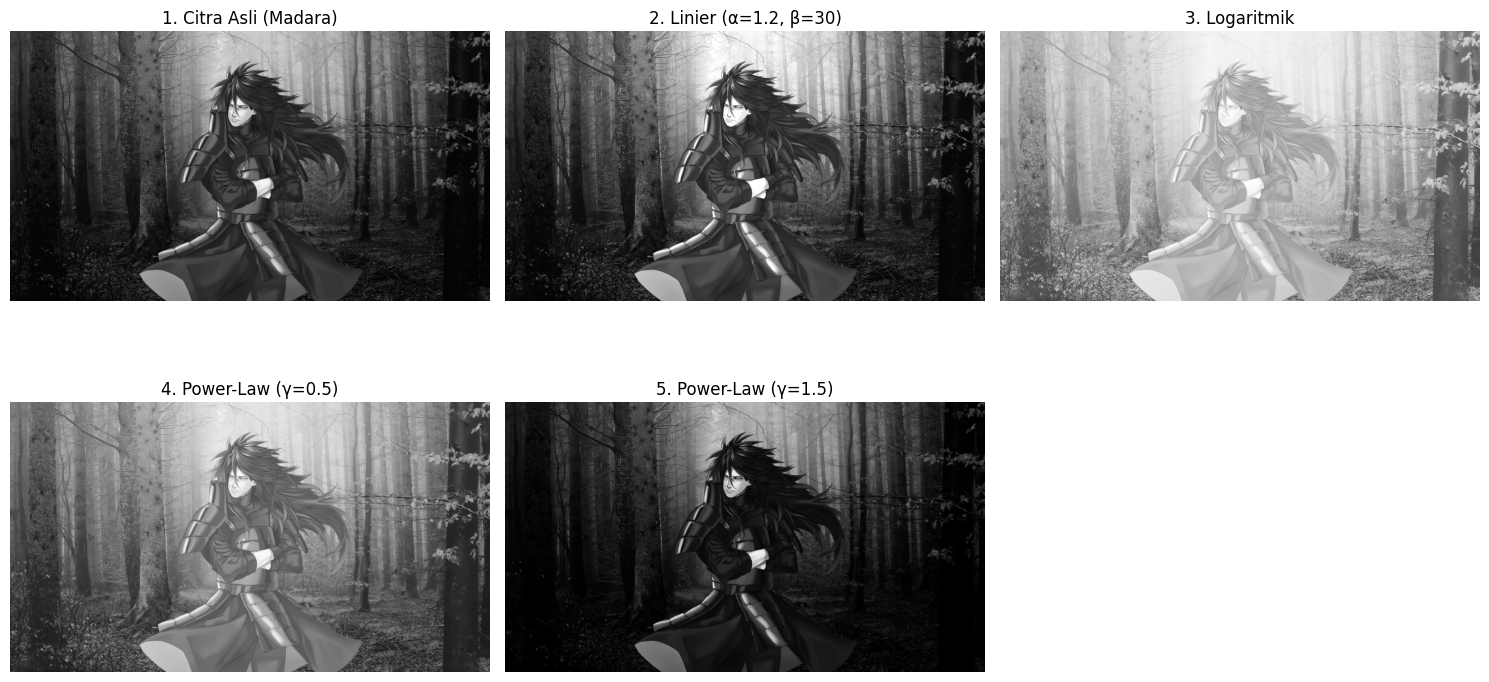

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def linear_transform(image, alpha, beta):
    """
    Transformasi Linier
    Rumus: s = alpha * r + beta
    """
    transformed = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return transformed

def log_transform(image):
    """
    Transformasi Logaritmik (Log Transform)
    Rumus: s = c * log(1 + r)
    """
    image_float = image.astype(float)
    c = 255 / np.log(1 + np.max(image_float))
    log_image = c * np.log(1 + image_float)
    return np.array(log_image, dtype=np.uint8)

def power_law_transform(image, gamma):
    """
    Transformasi Power-Law / Gamma Correction
    Rumus: s = c * r^gamma
    """
    image_normalized = image / 255.0
    power_law_image = np.power(image_normalized, gamma)
    return np.uint8(power_law_image * 255)

if __name__ == "__main__":
    # ========================================================
    # 1. BACA GAMBAR
    # Bagian ini sudah disesuaikan dengan nama gambar Anda
    # ========================================================
    img = cv2.imread('1331921.jpeg', cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Gambar '1331921.jpeg' tidak ditemukan. Pastikan gambar berada di folder yang sama dengan skrip Python.")
    else:
        # ========================================================
        # 2. TERAPKAN TRANSFORMASI
        # ========================================================
        # Transformasi Linier (Tingkatkan kontras 1.2x dan kecerahan +30)
        img_linear = linear_transform(img, alpha=1.2, beta=30)

        # Transformasi Logaritmik (Membuat area gelap seperti pepohonan lebih jelas)
        img_log = log_transform(img)

        # Transformasi Power Law (Gamma)
        img_gamma_low = power_law_transform(img, gamma=0.5)  # Menerangkan keseluruhan
        img_gamma_high = power_law_transform(img, gamma=1.5) # Menggelapkan, mempertegas bagian terang

        # ========================================================
        # 3. TAMPILKAN HASILNYA
        # ========================================================
        plt.figure(figsize=(15, 8))

        plt.subplot(2, 3, 1)
        plt.imshow(img, cmap='gray')
        plt.title("1. Citra Asli (Madara)")
        plt.axis('off')

        plt.subplot(2, 3, 2)
        plt.imshow(img_linear, cmap='gray')
        plt.title("2. Linier (α=1.2, β=30)")
        plt.axis('off')

        plt.subplot(2, 3, 3)
        plt.imshow(img_log, cmap='gray')
        plt.title("3. Logaritmik")
        plt.axis('off')

        plt.subplot(2, 3, 4)
        plt.imshow(img_gamma_low, cmap='gray')
        plt.title("4. Power-Law (γ=0.5)")
        plt.axis('off')

        plt.subplot(2, 3, 5)
        plt.imshow(img_gamma_high, cmap='gray')
        plt.title("5. Power-Law (γ=1.5)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()